In [25]:
from pathlib import Path
import re
from collections import defaultdict
import pandas as pd
import numpy as np

# exp_regex = r"\d{8}_\d{6}_exp_load_solver_(iterative|stable_point)_(\d+\.\d+)_(\d+)"
exp_regex = r"\d{8}_\d{6}_exp_param_budget_(\d+)_(\d+)"
folder = Path(".").resolve() / "experiments"

experiment_metrics = ["param", "variation"]
run_metrics = {
    "accuracy.txt": "accuracy",
    "power_entropy.txt": "pentropy",
    "speaker_entropy.txt": "sentropy",
}


columns = defaultdict(list)

for ent in folder.iterdir():

    if not ent.is_dir():
        continue

    res = re.findall(exp_regex, ent.name)

    if len(res) == 0:
        continue

    n_items = None
    for filename, name in run_metrics.items():

        with open(ent / filename, "r") as f:
            values = [float(v) for v in f.readlines()]

        n_items = len(values)
        columns[name].extend(values)


    for name, value in zip(experiment_metrics, res[0], strict=True):
        columns[name].extend([value] * n_items)

    columns["t"].extend(range(n_items))

    with open(ent / "test_metrics.txt", "r") as f:
        for line in f:
            name, metric = line.replace(" ", "").split("=")
            test_name = f"test_{name}"
            metric = float(metric)
            columns[test_name].extend([metric] * n_items)


df = pd.DataFrame(columns)

In [27]:
df["param"] = pd.to_numeric(df["param"])
df["variation"] = pd.to_numeric(df["variation"])

In [28]:
df

,accuracy,pentropy,sentropy,param,variation,t,test_accuracy,test_power_entropy,test_speaker_entropy,test_region_nmi
0,0.3293,0.9941,0.5403,10000,0,0,0.7049,0.190980,0.722529,0.339056
1,0.3345,0.9931,0.5956,10000,0,1,0.7049,0.190980,0.722529,0.339056
2,0.4028,0.9913,0.6368,10000,0,2,0.7049,0.190980,0.722529,0.339056
3,0.3712,0.9885,0.5810,10000,0,3,0.7049,0.190980,0.722529,0.339056
4,0.3885,0.9855,0.4915,10000,0,4,0.7049,0.190980,0.722529,0.339056
...,...,...,...,...,...,...,...,...,...,...
9595,0.9325,0.0789,0.3872,120000,3,295,0.9402,0.082693,0.380995,0.224357
9596,0.9300,0.0893,0.3785,120000,3,296,0.9402,0.082693,0.380995,0.224357
9597,0.9337,0.0833,0.3810,120000,3,297,0.9402,0.082693,0.380995,0.224357
9598,0.9387,0.0819,0.3900,120000,3,298,0.9402,0.082693,0.380995,0.224357


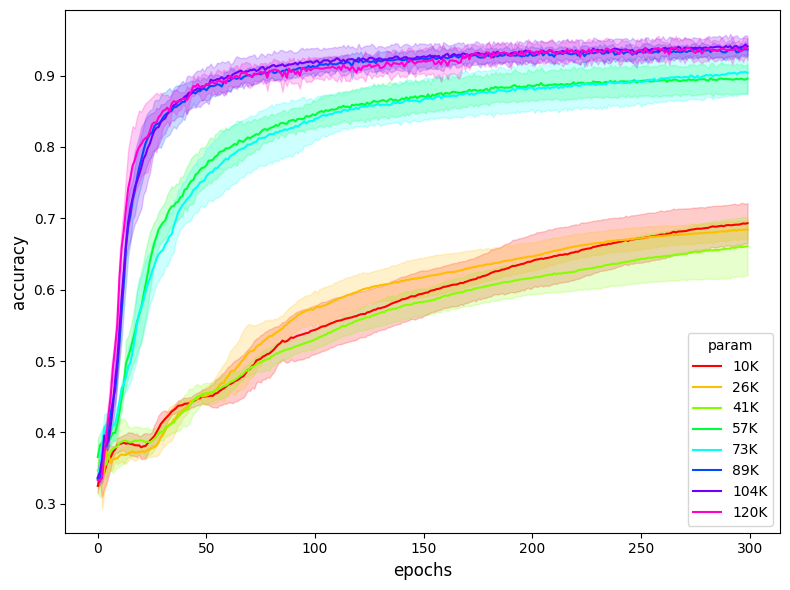

In [29]:
import matplotlib.pyplot as plt

def shaded_lines(df: pd.DataFrame, metric: str, group: str):
    means = df.groupby([group, "t"])[metric].mean()
    stds = df.groupby([group, "t"])[metric].std()

    means = means.unstack()
    stds = stds.unstack()

    means = means.sort_index(axis="columns")
    stds = stds.sort_index(axis="columns")

    fig, ax = plt.subplots(figsize=(8, 6))

    values_mu = means.to_numpy()
    values_std = stds.to_numpy()
    loads = means.index.to_numpy()
    colors = plt.colormaps["hsv"](np.arange(loads.size) / loads.size)
    epochs = values_mu.shape[1]
    epochs = np.arange(epochs)

    for i, (color, load) in enumerate(zip(colors, loads, strict=True)):
        ax.plot(epochs, values_mu[i, :], label=f"{round(load / 1_000)}K", color=color)
        ax.fill_between(epochs, values_mu[i, :] + values_std[i, :], values_mu[i, :] - values_std[i, :], color=color, alpha=0.2)

    # ax.set_xscale("log")
    ax.legend(title=group)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel("epochs", fontsize=12)
    fig.tight_layout()
    plt.show()

    return fig

fig = shaded_lines(df, "accuracy", "param")
fig.savefig("./figures/exp_param_accuracy.pdf")


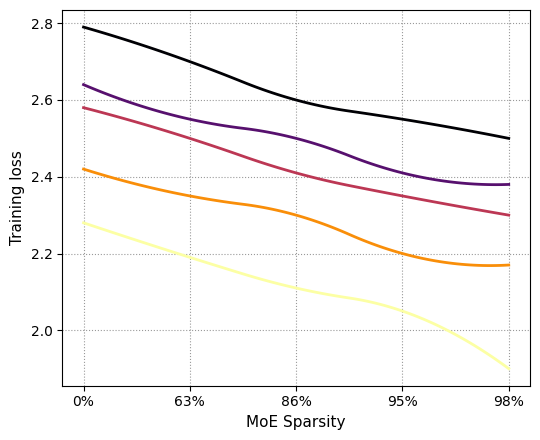

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

colors = [cm.inferno(i) for i in np.linspace(0, 1, 5)]

# -------------------------
# 1) Sample data
# -------------------------
# We assume 4 different "Total FLOPs C" curves (top to bottom).
# The x-axis (MoE Sparsity S) goes from 0% to ~98%.
# The y-axis (Optimal Pretraining Loss) ranges roughly from 2.0 to 2.8.
#
# You can tweak these data points to match your exact values.

labels = ["0%", "63%", "86%", "95%", "98%"]
x = np.array([0, 1, 2, 3, 4])
x_new = np.linspace(0, 4, 100)
y1 = np.array([2.79, 2.70, 2.6, 2.55, 2.50])  # Top (orange)
y2 = np.array([2.64, 2.55, 2.5, 2.41, 2.38])  # Next (red)
y3 = np.array([2.58, 2.5, 2.41, 2.35, 2.3])  # Next (dark red)
y4 = np.array([2.42, 2.35, 2.3, 2.2, 2.17])
y5 = np.array([2.28, 2.19, 2.11, 2.05, 1.9])

from scipy.interpolate import interp1d
import numpy as np


me = "quadratic"

f1 = interp1d(x, y1, kind=me)
f2 = interp1d(x, y2, kind=me)
f3 = interp1d(x, y3, kind=me)
f4 = interp1d(x, y4, kind=me)
f5 = interp1d(x, y5, kind=me)

y1_interp = f1(x_new)
y2_interp = f2(x_new)
y3_interp = f3(x_new)
y4_interp = f4(x_new)
y5_interp = f5(x_new)

# -------------------------
# 2) Plotting
# -------------------------
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# Choose colors close to those in the original figure

# Plot each line
ax.plot(x_new, y1_interp, color=colors[0], linewidth=2)
ax.plot(x_new, y2_interp, color=colors[1], linewidth=2)
ax.plot(x_new, y3_interp, color=colors[2], linewidth=2)
ax.plot(x_new, y4_interp, color=colors[3], linewidth=2)
ax.plot(x_new, y5_interp, color=colors[4], linewidth=2)

# -------------------------
# 3) Aesthetics
# -------------------------
# Grid lines (dotted), behind the data
ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle=':', color='gray', alpha=0.8)


# Ticks at the key sparsity points
ax.set_xticks(x, labels)

# Y ticks from 2.0 to 2.8 in steps of 0.2
ax.set_yticks(np.arange(2.0, 2.81, 0.2))

# Axis labels
ax.set_xlabel("MoE Sparsity", fontsize=11)
ax.set_ylabel(r"Training loss", fontsize=11)

plt.tight_layout()
plt.show()
